## Prep: Google Drive + Sam3

In [2]:
# 1. Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install numpy==1.26.4 # Install the version compatible with sam3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 52.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-

In [1]:
# 1. Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Sam3 repo
sam3_root = "drive/MyDrive/sam3/sam3" # sam3 설치 경로
# !git clone https://github.com/facebookresearch/sam3.git && mv sam3 drive/MyDrive/
!pip install drive/MyDrive/sam3 triton # Install sam3 and triton

import torch
import sys
import os
import matplotlib.pyplot as plt

# 3. GPU 최적화 설정 (Ampere 아키텍처 이상 추천)
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

# 4. Sam3 libs
import sam3
from PIL import Image
from sam3.model_builder import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

# 5. Sam3 model
from huggingface_hub import login
login(token="hf_REDACTED")

bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"
model = build_sam3_image_model(bpe_path=bpe_path)
processor = Sam3Processor(model, confidence_threshold=0.5)

Mounted at /content/drive
Processing ./drive/MyDrive/sam3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 8.1 MB/s eta 0:00:00
  Created wheel for sam3: filename=sam3-0.1.0-py3-none-any.whl size=2035309 sha256=b549472a50c149518e1216ac9a1e62d7c11b8366d87f73f238206248ba10a9f3
  Stored in directory: /tmp/pip-ephem-wheel-cache-f43meyux/wheels/a9/f6/56/8bceed5d64a938729b7cd9ea739ee815f543ed3684d47504b4
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=2c034fa22094640372ec904abe1663e10aff3952dbfc5aafb02304c67d0b32c7
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048

/usr/local/lib/python3.12/dist-packages/sam3/model/model_misc.py:70: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt: reconstructing file:   0%|          |  0.00B / 3.45GB            

sam3.pt: downloading bytes:           |  0.00B            

## EgoWaste DB
Load `meta_df`

### Comparing Multiple `detect_trash` Versions

To compare different versions of your detection logic, we can define separate functions (e.g., `detect_trash_v1`, `detect_trash_v2`) and run them sequentially or in parallel for the same input. The results from each version can then be stored and analyzed.

Let's define two simulated versions of `detect_trash` and modify the processing loop to execute both, storing their outcomes in separate lists.

https://colab.research.google.com/drive/1uHQBMfEirUcWUhBX-_R9coJ0qWZcJptN#scrollTo=mnXpoA3a-kUe&line=30&uniqifier=1 # Create a combined hand mask from the largest hand masks 부분은 다음과 같이 고쳐줘 두 영역을 합치지 말고, 두 개의 ROI를 별도로 처리하게 해줘. # Determine an expanded ROI around the combined hand mask 부분을 다음과 같이 고쳐줘. ROI에서 손 크기로 30% 확장하는 것을 네 방향으로 했는데, 플라스틱을 검출해서, 플라스틱의 박스가 ROI의 경계와 일치하는 방향에 대해서, 이미지 경계보다는 작으면, 그 방향으로 ROI에서 손 크기로 30% 확장해주고, 다시 플라스틱을 검출하도록 해줘. 플라스틱 박스가 이미지 경계에 도달했거나, 더 이상 ROI의 경계와 일치하지 않을 때까지.

In [ ]:
import os
import torch
from PIL import Image
import numpy as np # Added for converting torch tensors to numpy for Image.fromarray
import torch.nn.functional as F # Import for resizing masks
import pandas as pd # Added for meta_df
import matplotlib.pyplot as plt # Added for plotting in v2
from tqdm.notebook import tqdm # Import tqdm for progress bar
import pickle # Import the pickle module

# load meta_df
db_root = 'drive/MyDrive/camera1_plastics_shareable_dataset'
csv_file_path = f'{db_root}/camera1_plastics_meta2.csv'
original_external_root = '/media/jisha/E/trash_dataset/'
colab_equivalent_prefix = 'drive/MyDrive/'

try:
    meta_df = pd.read_csv(csv_file_path)
    print(f"Successfully loaded '{csv_file_path}' from within mnXpoA3a-kUe")
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found.")
except pd.errors.EmptyDataError:
    print(f"Error: The file '{csv_file_path}' is empty.")
except Exception as e:
    print(f"An unexpected error occurred while loading meta_df: {e}")

def compute_mask_iou(mask1: torch.Tensor, mask2: torch.Tensor) -> float:
    """
    Computes IoU between two binary masks.
    Args:
        mask1 (torch.Tensor): Binary mask tensor (H, W).
        mask2 (torch.Tensor): Binary mask tensor (H, W).
    Returns:
        float: IoU score.
    """
    # Ensure masks are boolean for logical operations
    mask1 = mask1.bool()
    mask2 = mask2.bool()

    intersection = torch.logical_and(mask1, mask2).sum()
    union = torch.logical_or(mask1, mask2).sum()
    if union == 0:
        return 0.0
    return intersection.float() / union.float()

def compute_bbox_iou(bbox1: list, bbox2: list) -> float:
    """
    Computes IoU between two bounding boxes [xmin, ymin, xmax, ymax].
    Args:
        bbox1 (list): First bounding box [xmin, ymin, xmax, ymax].
        bbox2 (list): Second bounding box [xmin, ymin, xmax, ymax].
    Returns:
        float: IoU score.
    """
    # Determine the coordinates of the intersection rectangle
    x_left = max(bbox1[0], bbox2[0])
    y_top = max(bbox1[1], bbox2[1])
    x_right = min(bbox1[2], bbox2[2])
    y_bottom = min(bbox1[3], bbox2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    # The intersection area
    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    # The area of each bounding box
    bbox1_area = (bbox1[2] - bbox1[0]) * (bbox1[3] - bbox1[1])
    bbox2_area = (bbox2[2] - bbox2[0]) * (bbox2[3] - bbox2[1])

    # The union area
    union_area = float(bbox1_area + bbox2_area - intersection_area)

    if union_area == 0:
        return 0.0

    return intersection_area / union_area

def compute_containment_ratio(bbox_plastic: list, bbox_hand: list) -> float:
    """
    Computes the ratio of the plastic bounding box's area that is contained within the hand bounding box.
    Args:
        bbox_plastic (list): Plastic bounding box [xmin, ymin, xmax, ymax].
        bbox_hand (list): Hand bounding box [xmin, ymin, xmax, ymax].
    Returns:
        float: Containment ratio of plastic bbox within hand bbox.
    """
    # Determine the coordinates of the intersection rectangle
    x_left = max(bbox_plastic[0], bbox_hand[0])
    y_top = max(bbox_plastic[1], bbox_hand[1])
    x_right = min(bbox_plastic[2], bbox_hand[2])
    y_bottom = min(bbox_plastic[3], bbox_hand[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    # The intersection area
    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    # The area of the plastic bounding box
    bbox_plastic_area = (bbox_plastic[2] - bbox_plastic[0]) * (bbox_plastic[3] - bbox_plastic[1])

    if bbox_plastic_area == 0: # Avoid division by zero if plastic bbox has zero area
        return 0.0

    return intersection_area / bbox_plastic_area

testPrompt = "hands"
def detect_trash_v1(frame_path, clip_path, visualize_debug_info=False):
    results_v1 = {
        'frame_path': frame_path,
        'clip_path': clip_path,
        'hand_detections': [],
        'plastic_in_hand_region_detections': [],
        'all_detected_plastic_for_analysis': [], # New list for all detected plastic for IoU with GT analysis
        'detection_status_v1': 'failed'
    }

    try:
        img_pil = Image.open(frame_path)
        original_width, original_height = img_pil.size

        # --- Step 1: Detect hands ---
        inference_state_hands = processor.set_image(img_pil)
        inference_state_hands = processor.set_text_prompt(state=inference_state_hands, prompt=testPrompt)

        hand_pred_boxes_raw = inference_state_hands.get('boxes', None)
        hand_masks_raw = inference_state_hands.get('masks', None)

        hand_regions_info = [] # Store info for each hand's ROI

        if hand_pred_boxes_raw is None or len(hand_pred_boxes_raw) == 0:
            # If no hands, plastic detection will default to full image (handled later)
            results_v1['detection_status_v1'] = 'no_hands_detected'
        else:
            # Calculate area for each hand bounding box
            hand_areas = (hand_pred_boxes_raw[:, 2] - hand_pred_boxes_raw[:, 0]) * \
                         (hand_pred_boxes_raw[:, 3] - hand_pred_boxes_raw[:, 1])

            # Sort hand bounding boxes by area and select the top 2
            sorted_indices = torch.argsort(hand_areas, descending=True)
            top_n_hands = min(2, len(hand_pred_boxes_raw))
            # print(f"{hand_areas=}, {sorted_indices=}") # Commented out for cleaner output

            for i in range(top_n_hands):
                hand_idx = sorted_indices[i]
                hand_bbox_xyxy = hand_pred_boxes_raw[hand_idx]
                hand_mask = hand_masks_raw[hand_idx]

                # Convert hand mask to 2D boolean if needed
                if hand_mask.ndim == 3: # If it's (1, H, W)
                    hand_mask_2d = hand_mask.squeeze(0).bool()
                else: # If it's already (H, W)
                    hand_mask_2d = hand_mask.bool()

                # Determine initial expanded ROI around this hand mask
                nonzero_coords_hand = torch.nonzero(hand_mask_2d)
                if nonzero_coords_hand.shape[0] > 0:
                    ymin_h, xmin_h = torch.min(nonzero_coords_hand, dim=0)[0]
                    ymax_h, xmax_h = torch.max(nonzero_coords_hand, dim=0)[0]

                    # Expand bounding box by 30% of original hand size
                    expansion_factor = 0.3
                    w_hand_orig = xmax_h - xmin_h
                    h_hand_orig = ymax_h - ymin_h
                    expand_x_amount = int(w_hand_orig * expansion_factor / 2)
                    expand_y_amount = int(h_hand_orig * expansion_factor / 2)

                    initial_roi_xmin = max(0, xmin_h.item() - expand_x_amount)
                    initial_roi_ymin = max(0, ymin_h.item() - expand_y_amount)
                    initial_roi_xmax = min(original_width, xmax_h.item() + expand_x_amount)
                    initial_roi_ymax = min(original_height, ymax_h.item() + expand_y_amount)

                    hand_regions_info.append({
                        'hand_idx': i,
                        'hand_bbox_original_coords': hand_bbox_xyxy.int().tolist(),
                        'hand_mask': hand_mask_2d,
                        'initial_roi_bounds': (initial_roi_xmin, initial_roi_ymin, initial_roi_xmax, initial_roi_ymax),
                        'hand_original_dims': (w_hand_orig, h_hand_orig)
                    })
                    results_v1['hand_detections'].append({
                        'hand_bbox_original_coords': hand_bbox_xyxy.int().tolist()
                    })

        # If no hands detected, create a single ROI for the full image
        if not hand_regions_info:
            hand_regions_info.append({
                'hand_idx': -1, # Indicates no specific hand
                'hand_bbox_original_coords': [0, 0, original_width, original_height], # Placeholder
                'hand_mask': torch.zeros(original_height, original_width, dtype=torch.bool, device=processor.device), # Empty mask
                'initial_roi_bounds': (0, 0, original_width, original_height),
                'hand_original_dims': (original_width, original_height) # Use full image dims for expansion basis
            })

        all_plastic_detections_in_hand = [] # This will still store filtered detections for visualization
        detected_any_plastic_in_hand_overall = False
        iou_threshold = 0.05 # This threshold now applies to bounding box IoU
        epsilon = 5 # Pixel buffer for boundary alignment check
        max_iterations = 5 # Safety break for iterative expansion
        expansion_factor = 0.6 # Consistent expansion factor

        for hand_region_info in hand_regions_info:
            current_hand_mask = hand_region_info['hand_mask']
            current_hand_bbox_original_coords = hand_region_info['hand_bbox_original_coords'] # Get hand bbox
            current_hand_original_dims = hand_region_info['hand_original_dims']
            hand_plastic_detections_for_this_hand = []

            # Initialize current ROI for this hand
            current_roi_xmin, current_roi_ymin, current_roi_xmax, current_roi_ymax = hand_region_info['initial_roi_bounds']

            iteration_count = 0
            while True:
                iteration_count += 1
                if iteration_count > max_iterations: # Prevent infinite loops
                    print(f"Max iterations ({max_iterations}) reached for hand_idx {hand_region_info['hand_idx']}. Breaking expansion loop.")
                    break

                current_roi_offset_x = current_roi_xmin
                current_roi_offset_y = current_roi_ymin
                current_roi_width = current_roi_xmax - current_roi_xmin
                current_roi_height = current_roi_ymax - current_roi_ymin

                if current_roi_width <= 0 or current_roi_height <= 0:
                    print(f"Invalid ROI dimensions for hand_idx {hand_region_info['hand_idx']}. Breaking expansion loop.")
                    break

                cropped_img_for_plastic_detection_pil = img_pil.crop((current_roi_xmin, current_roi_ymin, current_roi_xmax, current_roi_ymax))

                # --- Step 2: Detect plastic objects in the current ROI ---
                inference_state_plastic = processor.set_image(cropped_img_for_plastic_detection_pil)
                inference_state_plastic = processor.set_text_prompt(state=inference_state_plastic, prompt="plastic")

                plastic_pred_boxes_roi = inference_state_plastic.get('boxes', None)
                plastic_masks_roi = inference_state_plastic.get('masks', None)

                expansion_this_iteration = False
                next_roi_xmin, next_roi_ymin, next_roi_xmax, next_roi_ymax = current_roi_xmin, current_roi_ymin, current_roi_xmax, current_roi_ymax

                if plastic_pred_boxes_roi is not None and len(plastic_pred_boxes_roi) > 0:
                    for j, plastic_bbox_roi_xyxy in enumerate(plastic_pred_boxes_roi):
                        plastic_mask_tensor_roi = plastic_masks_roi[j]

                        # Ensure the plastic mask from SAM3 is 2D boolean (relative to ROI)
                        if plastic_mask_tensor_roi.ndim == 3:
                            plastic_mask_tensor_2d_roi_full = plastic_mask_tensor_roi.squeeze(0).bool()
                        else:
                            plastic_mask_tensor_2d_roi_full = plastic_mask_tensor_roi.bool()

                        # Convert plastic bbox from ROI coordinates back to original image coordinates
                        p_xmin_roi, p_ymin_roi, p_xmax_roi, p_ymax_roi = plastic_bbox_roi_xyxy.int().tolist()

                        # Calculate original coordinates (potentially out of bounds initially)
                        p_xmin_orig_raw = p_xmin_roi + current_roi_offset_x
                        p_ymin_orig_raw = p_ymin_roi + current_roi_offset_y
                        p_xmax_orig_raw = p_xmax_roi + current_roi_offset_x
                        p_ymax_orig_raw = p_ymax_roi + current_roi_offset_y

                        # Clamp these coordinates to the actual image boundaries
                        p_xmin_orig = max(0, p_xmin_orig_raw)
                        p_ymin_orig = max(0, p_ymin_orig_raw)
                        p_xmax_orig = min(original_width, p_xmax_orig_raw)
                        p_ymax_orig = min(original_height, p_ymax_orig_raw)

                        plastic_bbox_original_coords = [p_xmin_orig, p_ymin_orig, p_xmax_orig, p_ymax_orig]
                        # print(f"{iteration_count=} {j=}th obj, {plastic_bbox_original_coords=}", # Commented out for cleaner output
                        #       current_roi_xmin, current_roi_ymin, current_roi_xmax, current_roi_ymax)

                        # --- Check for ROI boundary alignment and expand if needed ---
                        w_hand_orig, h_hand_orig = current_hand_original_dims
                        expand_x_amount = int(w_hand_orig * expansion_factor / 2)
                        expand_y_amount = int(h_hand_orig * expansion_factor / 2)

                        # Check left boundary
                        if p_xmin_orig_raw <= current_roi_xmin + epsilon and current_roi_xmin > 0:
                            new_xmin = max(0, current_roi_xmin - expand_x_amount)
                            next_roi_xmin = min(next_roi_xmin, new_xmin)
                            expansion_this_iteration = True
                            # print(f"  Expanding left: p_xmin_orig_raw={p_xmin_orig_raw}, current_roi_xmin={current_roi_xmin}, new_xmin={new_xmin}, next_roi_xmin={next_roi_xmin})") # Commented out for cleaner output
                        # Check top boundary
                        if p_ymin_orig_raw <= current_roi_ymin + epsilon and current_roi_ymin > 0:
                            new_ymin = max(0, current_roi_ymin - expand_y_amount)
                            next_roi_ymin = min(next_roi_ymin, new_ymin)
                            expansion_this_iteration = True
                            # print(f"  Expanding top: p_ymin_orig_raw={p_ymin_orig_raw}, current_roi_ymin={current_roi_ymin}, new_ymin={new_ymin}, next_roi_ymin={next_roi_ymin})") # Commented out for cleaner output
                        # Check right boundary
                        if p_xmax_orig_raw >= current_roi_xmax - epsilon and current_roi_xmax < original_width:
                            new_xmax = min(original_width, current_roi_xmax + expand_x_amount)
                            next_roi_xmax = max(next_roi_xmax, new_xmax)
                            expansion_this_iteration = True
                            # print(f"  Expanding right: p_xmax_orig_raw={p_xmax_orig_raw}, current_roi_xmax={current_roi_xmax}, new_xmax={new_xmax}, next_roi_xmax={next_roi_xmax})") # Commented out for cleaner output
                        # Check bottom boundary
                        if p_ymax_orig_raw >= current_roi_ymax - epsilon and current_roi_ymax < original_height:
                            new_ymax = min(original_height, current_roi_ymax + expand_y_amount)
                            next_roi_ymax = max(next_roi_ymax, new_ymax)
                            expansion_this_iteration = True
                            # print(f"  Expanding bottom: p_ymax_orig_raw={p_ymax_orig_raw}, current_roi_ymax={current_roi_ymax}, new_ymax={new_ymax}, next_roi_ymax={next_roi_ymax})") # Commented out for cleaner output


                        # Crop the mask to the exact detected bounding box within the ROI
                        cropped_plastic_mask_in_roi = plastic_mask_tensor_2d_roi_full[p_ymin_roi:p_ymax_roi, p_xmin_roi:p_xmax_roi]

                        # Get target dimensions for the mask in original image coordinates
                        plastic_bbox_w = p_xmax_orig - p_xmin_orig
                        plastic_bbox_h = p_ymax_orig - p_ymin_orig

                        # Add check for valid dimensions before interpolation (both input and output sizes)
                        if plastic_bbox_h <= 0 or plastic_bbox_w <= 0 or \
                           cropped_plastic_mask_in_roi.shape[0] <= 0 or cropped_plastic_mask_in_roi.shape[1] <= 0:
                            print(f"Skipping plastic detection {j} for IoU calculation due to invalid bbox dimensions. Original bbox (H: {plastic_bbox_h}, W: {plastic_bbox_w}), Cropped ROI mask (H: {cropped_plastic_mask_in_roi.shape[0]}, W: {cropped_plastic_mask_in_roi.shape[1]})) ")
                            continue # Skip to the next plastic detection

                        # Resize the cropped mask to the exact dimensions it will occupy in the original image
                        temp_resized_mask = F.interpolate(
                            cropped_plastic_mask_in_roi.unsqueeze(0).unsqueeze(0).float(), # Add batch and channel dims for F.interpolate
                            size=(plastic_bbox_h, plastic_bbox_w),
                            mode='nearest' # Use nearest for binary masks
                        ).squeeze(0).squeeze(0).bool() # Remove added dims and convert back to bool

                        # Create a tensor of the exact target dimensions and copy content
                        final_mask_for_assignment = torch.zeros(
                            (plastic_bbox_h, plastic_bbox_w),
                                                                dtype=torch.bool,
                                                                device=temp_resized_mask.device)

                        copy_h = min(plastic_bbox_h, temp_resized_mask.shape[0])
                        copy_w = min(plastic_bbox_w, temp_resized_mask.shape[1])

                        final_mask_for_assignment[:copy_h, :copy_w] = temp_resized_mask[:copy_h, :copy_w]

                        full_size_plastic_mask_tensor = torch.zeros(
                            original_height, original_width,
                            dtype=torch.bool, device=plastic_mask_tensor_roi.device
                        )

                        # Place the resized mask into the full-sized mask at the correct offset
                        full_size_plastic_mask_tensor[
                            p_ymin_orig : p_ymax_orig,
                            p_xmin_orig : p_xmax_orig
                        ] = final_mask_for_assignment

                        # Add ALL detected plastic to a temporary list for analysis, regardless of hand IoU
                        results_v1['all_detected_plastic_for_analysis'].append({
                            'plastic_bbox_original_coords': plastic_bbox_original_coords,
                            'plastic_mask_original_coords': full_size_plastic_mask_tensor, # Store full mask for analysis
                        })

                        # --- Use containment ratio here ---
                        iou_score_plastic_with_hand = 0.0
                        if current_hand_bbox_original_coords:
                            iou_score_plastic_with_hand = compute_containment_ratio(
                                plastic_bbox_original_coords, current_hand_bbox_original_coords
                            )
                            # print(f"  Containment Ratio for plastic detection {j} (in hand): {iou_score_plastic_with_hand:.4f}") # Commented out for cleaner output

                        # Only store detections that have significant overlap with the hand
                        if iou_score_plastic_with_hand > iou_threshold:
                            detected_any_plastic_in_hand_overall = True
                            hand_plastic_detections_for_this_hand.append({
                                'hand_idx': hand_region_info['hand_idx'],
                                'plastic_bbox_original_coords': plastic_bbox_original_coords,
                                'plastic_mask_original_coords': full_size_plastic_mask_tensor, # Store full mask for visualization
                                'iou_plastic_with_hand': iou_score_plastic_with_hand # Store containment ratio
                            })


                if not expansion_this_iteration:
                    break # No further expansion needed for this hand
                else:
                    # print(f"  ROI expanded. Old: ({current_roi_xmin}, {current_roi_ymin}, {current_roi_xmax}, {current_roi_ymax}) -> New: ({next_roi_xmin}, {next_roi_ymin}, {next_roi_xmax}, {next_roi_ymax})") # Commented out for cleaner output
                    current_roi_xmin, current_roi_ymin, current_roi_xmax, current_roi_ymax = next_roi_xmin, next_roi_ymin, next_roi_xmax, next_roi_ymax

            # Store the final ROI bounds for this hand after all iterations
            hand_region_info['final_roi_bounds'] = (current_roi_xmin, current_roi_ymin, current_roi_xmax, current_roi_ymax)

            # Add all unique plastic detections for this hand to the overall filtered list for visualization
            for plastic_det in hand_plastic_detections_for_this_hand:
                # Avoid duplicate detections (e.g., if re-detected in expanded ROI)
                is_duplicate = False
                for existing_det in all_plastic_detections_in_hand:
                    if existing_det['plastic_bbox_original_coords'] == plastic_det['plastic_bbox_original_coords']:
                        is_duplicate = True
                        break
                if not is_duplicate:
                    all_plastic_detections_in_hand.append(plastic_det)


        results_v1['plastic_in_hand_region_detections'] = all_plastic_detections_in_hand

        if detected_any_plastic_in_hand_overall:
            results_v1['detection_status_v1'] = 'processed_with_hands_and_plastic'
        elif len(results_v1['hand_detections']) > 0:
            results_v1['detection_status_v1'] = 'no_significant_plastic_in_hand'
        elif len(results_v1['all_detected_plastic_for_analysis']) > 0: # Plastic detected in full image ROI (no hands), using unfiltered list now
            results_v1['detection_status_v1'] = 'no_hands_plastic_in_image'
        else:
            results_v1['detection_status_v1'] = 'no_plastic_or_hands'

        # --- Visualization ---
        all_pred_boxes = []
        all_masks = []
        all_labels = []
        all_scores = [] # Initialize list for scores

        # Add individual hand detections
        if hand_pred_boxes_raw is not None and len(hand_pred_boxes_raw) > 0:
            for i, hand_box in enumerate(hand_pred_boxes_raw):
                all_pred_boxes.append(hand_box.unsqueeze(0)) # Add as (1,4) tensor
                all_labels.append(f"Hand {i}")
                hand_mask_for_vis = hand_masks_raw[i]
                if hand_mask_for_vis.ndim == 3:
                    all_masks.append(hand_mask_for_vis.squeeze(0).bool().unsqueeze(0))
                else:
                    all_masks.append(hand_mask_for_vis.bool().unsqueeze(0))
                all_scores.append(torch.tensor([1.0], device=processor.device)) # Placeholder score


        # Add plastic detections associated with hands (these are still filtered by IoU with hand)
        if results_v1['plastic_in_hand_region_detections']:
            for j, plastic_detection_info in enumerate(results_v1['plastic_in_hand_region_detections']):
                p_xmin_orig_vis, p_ymin_orig_vis, p_xmax_orig_vis, p_ymax_orig_vis = plastic_detection_info['plastic_bbox_original_coords']
                all_pred_boxes.append(torch.tensor([[p_xmin_orig_vis, p_ymin_orig_vis, p_xmax_orig_vis, p_ymax_orig_vis]], dtype=torch.float32, device=processor.device))

                full_size_plastic_mask_tensor_vis = plastic_detection_info['plastic_mask_original_coords']

                all_masks.append(full_size_plastic_mask_tensor_vis.unsqueeze(0))

                iou_val_hand = plastic_detection_info.get('iou_plastic_with_hand', -1.0)
                all_labels.append(f"Plastic {plastic_det_idx} (Cont. Ratio: {iou_val_hand:.2f})") # Corrected variable name
                all_scores.append(torch.tensor([1.0], device=processor.device)) # Placeholder score

        # --- Debug Visualization (New) ---
        if visualize_debug_info:
            # Visualize Final ROIs
            for i_hand, hand_region_info in enumerate(hand_regions_info): # Changed loop variable to avoid conflict
                if 'final_roi_bounds' in hand_region_info:
                    roi_xmin, roi_ymin, roi_xmax, roi_ymax = hand_region_info['final_roi_bounds']
                    # Add ROI bounding box
                    all_pred_boxes.append(torch.tensor([[roi_xmin, roi_ymin, roi_xmax, roi_ymax]], dtype=torch.float32, device=processor.device))
                    all_labels.append(f"Final ROI Hand {hand_region_info['hand_idx']}")
                    # Create an empty mask for ROI to maintain 1:1 mapping with boxes for plot_results
                    roi_mask_for_vis = torch.zeros(original_height, original_width, dtype=torch.bool, device=processor.device)
                    all_masks.append(roi_mask_for_vis.unsqueeze(0))
                    all_scores.append(torch.tensor([0.0], device=processor.device)) # Placeholder score for ROI

        # NOTE: Ground truth mask visualization removed from within detect_trash_v1
        # It should be handled externally for evaluation and plotting.

        if len(all_pred_boxes) > 0:
            final_pred_boxes_tensor = torch.cat(all_pred_boxes, dim=0)
            stacked_all_masks = torch.cat(all_masks, dim=0).float() if all_masks else torch.empty(0, 1, original_height, original_width, device=processor.device)
            final_scores_tensor = torch.cat(all_scores, dim=0) if all_scores else torch.empty(0, device=processor.device)

            plot_results_dict = {
                'boxes': final_pred_boxes_tensor,
                'masks': stacked_all_masks,
                'phrases': all_labels,
                'scores': final_scores_tensor
            }

            fig = plot_results(img_pil, plot_results_dict)
        # else:
            # print("No detections or ground truth to visualize.") # Commented out for cleaner output

    except Exception as e:
        results_v1['detection_status_v1'] = f'error: {e}'
        print(f"Error processing {frame_path}: {e}")

    results_v1['hand_regions_processed_info'] = hand_regions_info # Store for external visualization
    return results_v1

def detect_trash_v2(frame_path, clip_path, expected_mask_path):
    """
    Detects and visualizes the top 5 plastic objects in the full image.
    """
    results_v2 = {
        'frame_path': frame_path,
        'clip_path': clip_path,
        'detection_status_v2': 'failed',
        'top_k_plastic_boxes': [], # Store top K boxes
        'top_k_plastic_masks': [], # Store top K masks
        'top_k_plastic_scores': [] # Store top K scores
    }

    try:
        img_pil = Image.open(frame_path)
        original_width, original_height = img_pil.size

        # Perform plastic detection on the full image
        inference_state_plastic_full_image = processor.set_image(img_pil)
        inference_state_plastic_full_image = processor.set_text_prompt(state=inference_state_plastic_full_image, prompt="plastic")

        plastic_pred_boxes = inference_state_plastic_full_image.get('boxes', None)
        plastic_masks = inference_state_plastic_full_image.get('masks', None)
        plastic_scores = inference_state_plastic_full_image.get('scores', None)

        if plastic_pred_boxes is not None and len(plastic_pred_boxes) > 0:
            # Sort by scores in descending order
            sorted_indices = torch.argsort(plastic_scores, descending=True)
            top_5_indices = sorted_indices[:5] # Get indices of top 5 scores

            top_5_boxes = plastic_pred_boxes[top_5_indices]
            top_5_masks = plastic_masks[top_5_indices]
            top_5_scores = plastic_scores[top_5_indices]

            # Store the top K results in results_v2
            results_v2['top_k_plastic_boxes'] = top_5_boxes.tolist() if top_5_boxes is not None else []
            results_v2['top_k_plastic_masks'] = [mask.cpu() for mask in top_5_masks] if top_5_masks is not None else [] # Move to CPU for easier handling
            results_v2['top_k_plastic_scores'] = top_5_scores.tolist() if top_5_scores is not None else []

            results_v2['detection_status_v2'] = 'processed_top5_plastic'

        else:
            results_v2['detection_status_v2'] = 'no_plastic_detected'
            print(f"No plastic detected in {os.path.basename(frame_path)} for V2.")

    except Exception as e:
        results_v2['detection_status_v2'] = f'error: {e}'
        print(f"Error processing {frame_path} with V2: {e}")

    return results_v2

def process_frame_path(frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root):
    """
    Processes a raw frame file suffix to construct a full, accessible frame path.

    Args:
        frame_file_suffix (str): The suffix or full path of the frame file.
        original_external_root (str): The original external root directory.
        colab_equivalent_prefix (str): The Colab equivalent prefix for paths.
        db_root (str): The root directory of the database.

    Returns:
        str: The full, processed path to the frame file.
    """
    # Process frame path
    if frame_file_suffix.startswith(original_external_root):
        frame_path_temp = frame_file_suffix.replace(original_external_root, colab_equivalent_prefix)
    else:
        frame_path_temp = frame_file_suffix

    if frame_path_temp.startswith(db_root):
        relative_part_frame = frame_path_temp[len(db_root):]
        if relative_part_frame.startswith('/') or relative_part_frame.startswith('\\'):
            relative_part_frame = relative_part_frame[1:]
        full_frame_path = os.path.join(db_root, relative_part_frame)
    else:
        full_frame_path = os.path.join(db_root, frame_path_temp)

    return full_frame_path

detection_results_v1 = [] # This list will now accumulate results of the current run
detection_results_v2 = [] # This list will now accumulate results of the current run

# Define directories for individual checkpoint files
save_dir_results = 'drive/MyDrive/csire_code/segment/sam3_whole'
save_dir_v1_individual_results = os.path.join(save_dir_results, 'v1_individual_results')
save_dir_v2_individual_results = os.path.join(save_dir_results, 'v2_individual_results')
os.makedirs(save_dir_v1_individual_results, exist_ok=True)
os.makedirs(save_dir_v2_individual_results, exist_ok=True)

# Set test_limit to an integer (e.g., 5) to process only the first N files.
# Set test_limit = None to process all files in meta_df.
test_limit = None # Change to None to process all files

# The processing loop will always start from the beginning and either load or process each frame.
# The 'initial' parameter for tqdm will track actual processed frames, not skipped ones.

# Iterate through each row of the meta_df DataFrame with a tqdm progress bar
for i, row in tqdm(meta_df.iterrows(),
                  total=len(meta_df),
                  desc="Processing frames"):

    frame_file_suffix = row['copied_frame_path']
    mask_file_suffix = row['copied_mask_path']
    clip_file_suffix = row['timestamp_clip_path']

    # Use the helper function to process paths
    full_frame_path = process_frame_path(
        frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root
    )

    full_mask_path = None
    if pd.notna(mask_file_suffix):
        full_mask_path = process_frame_path(
            mask_file_suffix, original_external_root, colab_equivalent_prefix, db_root
        )

    full_clip_path = None
    if pd.notna(clip_file_suffix):
        full_clip_path = process_frame_path(
            clip_file_suffix, original_external_root, colab_equivalent_prefix, db_root
        )
    '''
    # --- Checkpointing and processing for detect_trash_v1 ---
    v1_result_filename = f"v1_result_{i:06d}.pkl"
    v1_result_path = os.path.join(save_dir_v1_individual_results, v1_result_filename)

    result_v1 = None
    if os.path.exists(v1_result_path):
        try:
            with open(v1_result_path, 'rb') as f:
                result_v1 = pickle.load(f)
            # print(f"Loaded v1 result for frame {i} from checkpoint.") # Commented out for cleaner output
        except Exception as e:
            print(f"Error loading v1 result for frame {i} from {v1_result_path}: {e}. Re-processing.")
            result_v1 = None # Force re-processing if load fails

    if result_v1 is None:
        result_v1 = detect_trash_v1(full_frame_path, full_clip_path, visualize_debug_info=False) # Changed to False to prevent excessive plots
        result_v1['ground_truth_mask_path'] = full_mask_path
        try:
            with open(v1_result_path, 'wb') as f:
                pickle.dump(result_v1, f)
            # print(f"Processed and saved v1 result for frame {i}.") # Commented out for cleaner output
        except Exception as e:
            print(f"Error saving v1 result for frame {i} to {v1_result_path}: {e}")
    detection_results_v1.append(result_v1)
    '''
    # --- Checkpointing and processing for detect_trash_v2 ---
    v2_result_filename = f"v2_result_{i:06d}.pkl"
    v2_result_path = os.path.join(save_dir_v2_individual_results, v2_result_filename)

    result_v2 = None
    if os.path.exists(v2_result_path):
        try:
            with open(v2_result_path, 'rb') as f:
                result_v2 = pickle.load(f)
            # print(f"Loaded v2 result for frame {i} from checkpoint.") # Commented out for cleaner output
        except Exception as e:
            print(f"Error loading v2 result for frame {i} from {v2_result_path}: {e}. Re-processing.")
            result_v2 = None # Force re-processing if load fails

    if result_v2 is None:
        result_v2 = detect_trash_v2(full_frame_path, full_clip_path, full_mask_path)
        result_v2['expected_mask_path'] = full_mask_path # Add mask path to v2 results for IoU calculation
        try:
            with open(v2_result_path, 'wb') as f:
                pickle.dump(result_v2, f)
            # print(f"Processed and saved v2 result for frame {i}.") # Commented out for cleaner output
        except Exception as e:
            print(f"Error saving v2 result for frame {i} to {v2_result_path}: {e}")
    detection_results_v2.append(result_v2)

    if test_limit is not None and (i + 1) >= test_limit:
        print(f"Reached test_limit of {test_limit} frames. Stopping processing.")
        break

# Final print statement to indicate completion of the processing loop
print("Finished processing all frames for detect_trash_v1 and detect_trash_v2 (or reached test_limit).")

# Display summary of results
print(f"\nTotal items processed by V1 in this run: {len(detection_results_v1)}")
print(f"Total items processed by V2 in this run: {len(detection_results_v2)}")

# The aggregated results (merged_detection_results_v1 and merged_detection_results_v2)
# will be loaded in separate cells (c1cb32f0 and f6cfc086 respectively) from individual files
# for evaluation, not from these in-memory lists.

# To see the results, you can uncomment these lines:
# display(pd.DataFrame(detection_results_v1).head())
# display(pd.DataFrame(detection_results_v2).head())

Successfully loaded 'drive/MyDrive/camera1_plastics_shareable_dataset/camera1_plastics_meta2.csv' from within mnXpoA3a-kUe


Processing frames:   0%|          | 0/3538 [00:00<?, ?it/s]

In [ ]:
'''import os
import pickle

# Define the directory where v1 individual results are saved
save_dir_results = 'drive/MyDrive/csire_code/segment/sam3_whole'
save_dir_v1_individual_results = os.path.join(save_dir_results, 'v1_individual_results')

# Load and merge all v1 individual result files
merged_detection_results_v1 = []
if os.path.exists(save_dir_v1_individual_results):
    result_files = sorted([f for f in os.listdir(save_dir_v1_individual_results) if f.startswith('v1_result_') and f.endswith('.pkl')])
    for rf in result_files:
        result_path = os.path.join(save_dir_v1_individual_results, rf)
        try:
            with open(result_path, 'rb') as f:
                single_frame_result = pickle.load(f)
                merged_detection_results_v1.append(single_frame_result)
        except Exception as e:
            print(f"Error loading V1 result file {rf}: {e}")
    print(f"Successfully loaded and merged {len(merged_detection_results_v1)} V1 results for analysis.")
else:
    print(f"No v1 individual results directory found at {save_dir_v1_individual_results}. Skipping loading.")

In [ ]:
'''import os
import pickle
from tqdm.notebook import tqdm

# Define the directory where v2 individual results are saved
save_dir_results = 'drive/MyDrive/csire_code/segment/sam3_whole'
save_dir_v2_individual_results = os.path.join(save_dir_results, 'v2_individual_results')

# Load and merge all v2 individual result files
merged_detection_results_v2 = []
if os.path.exists(save_dir_v2_individual_results):
    result_files = sorted([f for f in os.listdir(save_dir_v2_individual_results) if f.startswith('v2_result_') and f.endswith('.pkl')])
    for rf in tqdm(result_files):
        result_path = os.path.join(save_dir_v2_individual_results, rf)
        try:
            with open(result_path, 'rb') as f:
                single_frame_result = pickle.load(f)
                merged_detection_results_v2.append(single_frame_result)
        except Exception as e:
            print(f"Error loading V2 result file {rf}: {e}")
    print(f"Successfully loaded and merged {len(merged_detection_results_v2)} V2 results for analysis.")
else:
    print(f"No v2 individual results directory found at {save_dir_v2_individual_results}. Skipping loading.")
detection_results_v2 = merged_detection_results_v2

  0%|          | 0/3117 [00:00<?, ?it/s]

Successfully loaded and merged 3117 V2 results for analysis.


In [ ]:
import numpy as np
import torch
import os
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure compute_mask_iou is defined (re-define for self-containment if not guaranteed global)
def compute_mask_iou(mask1: torch.Tensor, mask2: torch.Tensor) -> float:
    """
    Computes IoU between two binary masks.
    Args:
        mask1 (torch.Tensor): Binary mask tensor (H, W).
        mask2 (torch.Tensor): Binary mask tensor (H, W).
    Returns:
        float: IoU score.
    """
    mask1 = mask1.bool()
    mask2 = mask2.bool()

    intersection = torch.logical_and(mask1, mask2).sum()
    union = torch.logical_or(mask1, mask2).sum()
    if union == 0:
        return 0.0
    return intersection.float() / union.float()

all_max_ious_top1 = []
all_max_ious_top3 = []
all_max_ious_top5 = []

print("Calculating IoU scores for detect_trash_v2 results...")

for result_v2_entry in detection_results_v2:
    frame_path = result_v2_entry['frame_path']
    ground_truth_mask_path = result_v2_entry['expected_mask_path'] # Using 'expected_mask_path' from v2 result

    if ground_truth_mask_path and os.path.exists(ground_truth_mask_path):
        try:
            gt_mask_pil = Image.open(ground_truth_mask_path).convert('L') # Convert to grayscale

            # Load original image to get its dimensions for resizing GT mask if needed
            img_pil_orig = Image.open(frame_path)
            original_width, original_height = img_pil_orig.size

            if gt_mask_pil.size != (original_width, original_height):
                gt_mask_pil = gt_mask_pil.resize((original_width, original_height), Image.NEAREST)

            ground_truth_mask_tensor = torch.from_numpy(np.array(gt_mask_pil)).bool() # Keep on CPU

            top_k_plastic_masks = result_v2_entry['top_k_plastic_masks'] # These are already on CPU

            if top_k_plastic_masks:
                ious_for_frame = []
                for detected_plastic_mask_cpu in top_k_plastic_masks:
                    # Ensure detected_plastic_mask_cpu is resized to match GT mask if necessary
                    if detected_plastic_mask_cpu.shape != ground_truth_mask_tensor.shape:
                        # If it's a 2D mask, unsqueeze for F.interpolate and then squeeze back
                        detected_plastic_mask_cpu_resized = torch.nn.functional.interpolate(
                            detected_plastic_mask_cpu.float().unsqueeze(0).unsqueeze(0),
                            size=(original_height, original_width),
                            mode='nearest'
                        ).squeeze(0).squeeze(0).bool()
                    else:
                        detected_plastic_mask_cpu_resized = detected_plastic_mask_cpu.bool()

                    iou_score = compute_mask_iou(detected_plastic_mask_cpu_resized, ground_truth_mask_tensor)
                    ious_for_frame.append(iou_score.item())

                # Ensure ious_for_frame is sorted by detection score (implicit from top_k_plastic_masks)
                # Take max IoU for top 1, top 3, top 5
                if ious_for_frame:
                    all_max_ious_top1.append(max(ious_for_frame[:1])) # Max of first element
                else:
                    all_max_ious_top1.append(0.0) # No detections

                if len(ious_for_frame) >= 3:
                    all_max_ious_top3.append(max(ious_for_frame[:3])) # Max of first three elements
                elif ious_for_frame:
                    all_max_ious_top3.append(max(ious_for_frame)) # Max of available if less than 3 but not empty
                else:
                    all_max_ious_top3.append(0.0)

                if len(ious_for_frame) >= 5:
                    all_max_ious_top5.append(max(ious_for_frame[:5])) # Max of first five elements
                elif ious_for_frame:
                    all_max_ious_top5.append(max(ious_for_frame)) # Max of available if less than 5 but not empty
                else:
                    all_max_ious_top5.append(0.0)

            else:
                # No plastic detections for this frame
                all_max_ious_top1.append(0.0)
                all_max_ious_top3.append(0.0)
                all_max_ious_top5.append(0.0)

        except Exception as e:
            print(f"Error processing ground truth mask {ground_truth_mask_path} for frame {frame_path}: {e}")
            all_max_ious_top1.append(0.0)
            all_max_ious_top3.append(0.0)
            all_max_ious_top5.append(0.0)
    else:
        print(f"Ground truth mask not found or path not specified for frame: {frame_path}")
        all_max_ious_top1.append(0.0)
        all_max_ious_top3.append(0.0)
        all_max_ious_top5.append(0.0)

print("\n--- IoU Metrics for detect_trash_v2 (Top K Detections) ---")

metrics_df = pd.DataFrame({
    'Max_IoU_Top1': all_max_ious_top1,
    'Max_IoU_Top3': all_max_ious_top3,
    'Max_IoU_Top5': all_max_ious_top5
})

if not metrics_df.empty:
    # Define a save path for the metrics dataframe
    metrics_save_path = 'drive/MyDrive/csire_code/segment/sam3_whole/iou_metrics_v2.csv'
    os.makedirs(os.path.dirname(metrics_save_path), exist_ok=True)
    metrics_df.to_csv(metrics_save_path, index=False)
    print(f"IoU metrics saved to {metrics_save_path}")

    print("\nSummary Statistics for Max IoU (Top 1):")
    print(metrics_df['Max_IoU_Top1'].describe())

    print("\nSummary Statistics for Max IoU (Top 3):")
    print(metrics_df['Max_IoU_Top3'].describe())

    print("\nSummary Statistics for Max IoU (Top 5):")
    print(metrics_df['Max_IoU_Top5'].describe())

    # Display a histogram for each top K IoU
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    sns.histplot(metrics_df['Max_IoU_Top1'], bins=20, kde=True)
    plt.title('Distribution of Max IoU (Top 1)')
    plt.xlabel('Max IoU Score')
    plt.ylabel('Frequency')

    plt.subplot(1, 3, 2)
    sns.histplot(metrics_df['Max_IoU_Top3'], bins=20, kde=True)
    plt.title('Distribution of Max IoU (Top 3)')
    plt.xlabel('Max IoU Score')
    plt.ylabel('Frequency')

    plt.subplot(1, 3, 3)
    sns.histplot(metrics_df['Max_IoU_Top5'], bins=20, kde=True)
    plt.title('Distribution of Max IoU (Top 5)')
    plt.xlabel('Max IoU Score')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

else:
    print("No IoU scores to analyze for detect_trash_v2.")

print("--- Finished IoU analysis for detect_trash_v2 ---")


--- Starting visualization of detected plastics in cropped ROIs ---

Visualizing ROIs for Frame 1 (GX010023__frame_000018.jpg)

  Visualizing Hand ROI 0 (Original Coords: (67, 188, 441, 533))
found 7 object(s)


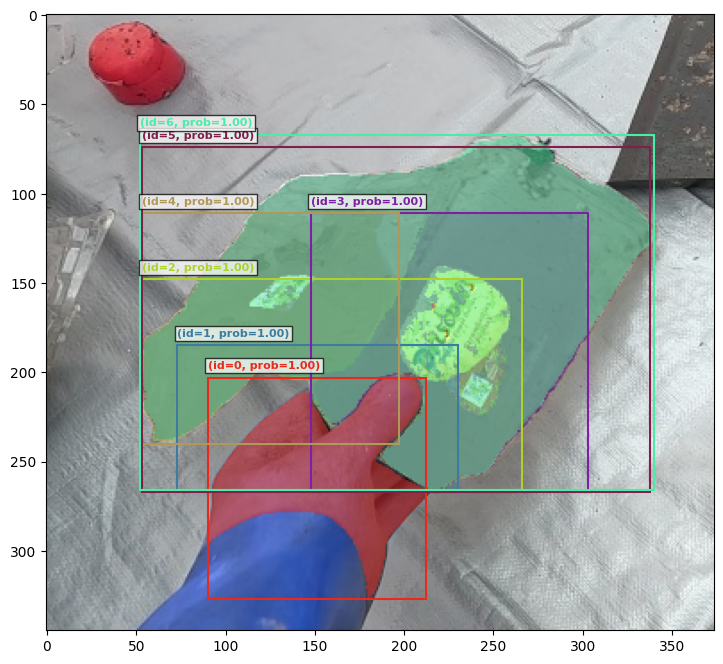

  Visualizing Hand ROI 1 (Original Coords: (430, 323, 1024, 576))
found 10 object(s)


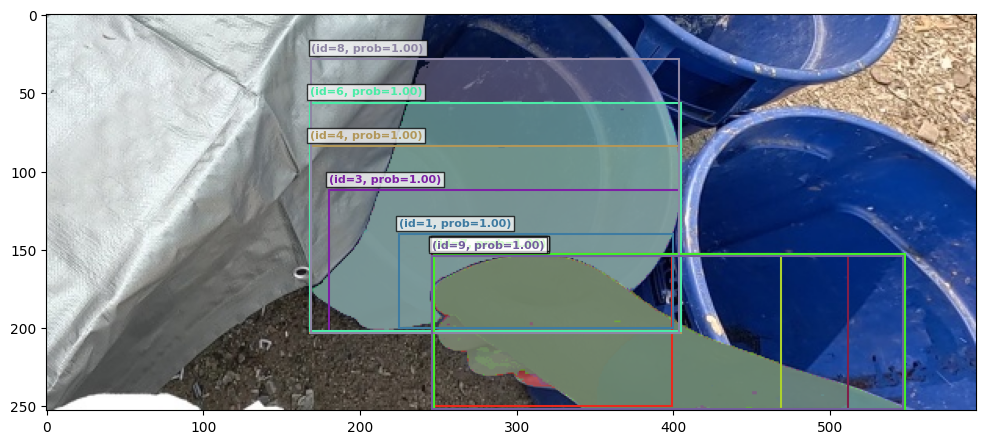


Visualizing ROIs for Frame 2 (GX010023__frame_000019.jpg)

  Visualizing Hand ROI 0 (Original Coords: (425, 264, 1024, 576))
found 16 object(s)


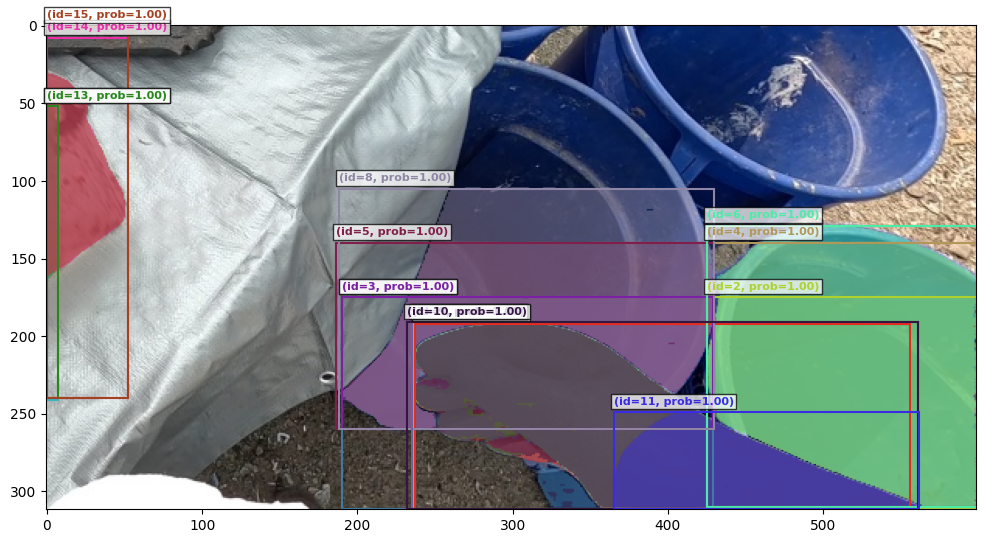

  Visualizing Hand ROI 1 (Original Coords: (4, 228, 532, 576))
found 7 object(s)


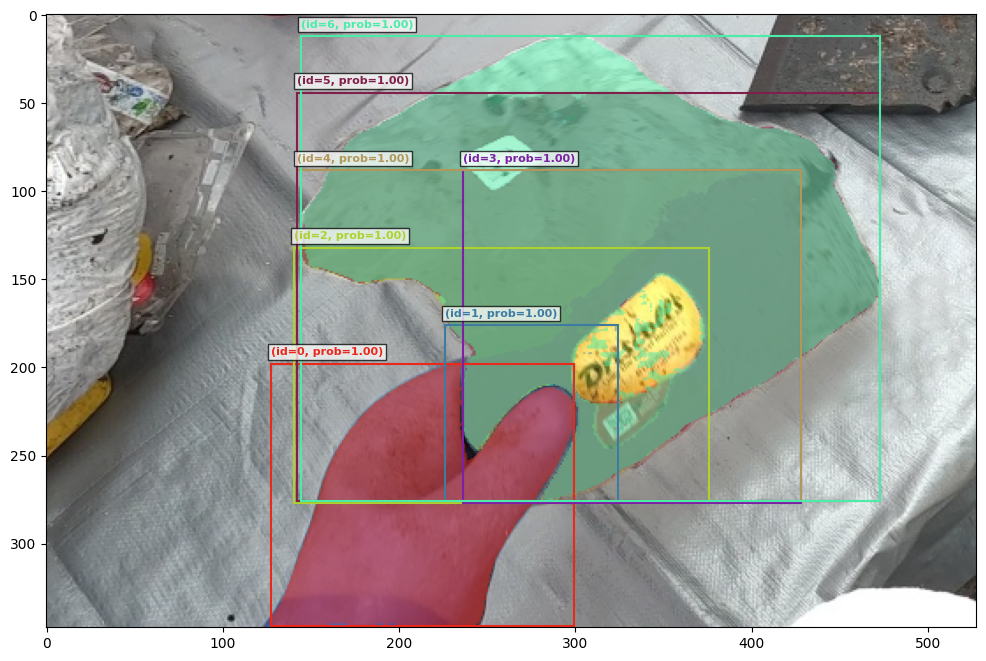


--- Finished visualization of detected plastics in cropped ROIs ---


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import torch

print("\n--- Starting visualization of detected plastics in cropped ROIs ---")

# Ensure plot_results is available (it's imported in the setup cell already)
# from sam3.visualization_utils import plot_results

for i, result in enumerate(detection_results_v1):
    frame_path = result['frame_path']
    img_pil_full = Image.open(frame_path)

    print(f"\nVisualizing ROIs for Frame {i+1} ({os.path.basename(frame_path)})\n")

    # Iterate through each processed hand region (which defines an ROI)
    if 'hand_regions_processed_info' in result and result['hand_regions_processed_info']:
        for hand_info_idx, hand_region_info in enumerate(result['hand_regions_processed_info']):
            if 'final_roi_bounds' in hand_region_info:
                roi_xmin, roi_ymin, roi_xmax, roi_ymax = hand_region_info['final_roi_bounds']

                # Skip if ROI dimensions are invalid
                if roi_xmax <= roi_xmin or roi_ymax <= roi_ymin:
                    print(f"  Skipping visualization for Hand ROI {hand_info_idx} due to invalid ROI dimensions: ({roi_xmin}, {roi_ymin}, {roi_xmax}, {roi_ymax})")
                    continue

                # Crop the original image to the current ROI
                cropped_img_roi = img_pil_full.crop((roi_xmin, roi_ymin, roi_xmax, roi_ymax))
                roi_cropped_width, roi_cropped_height = cropped_img_roi.size

                roi_plot_boxes = []
                roi_plot_masks = []
                roi_plot_labels = []
                roi_plot_scores = []

                # Add the hand mask (cropped to ROI) if it exists and has content within this ROI
                if hand_region_info['hand_mask'] is not None and hand_region_info['hand_mask'].sum() > 0:
                    hand_mask_full = hand_region_info['hand_mask']
                    # Crop the full-size hand mask to the current ROI boundaries
                    cropped_hand_mask_for_roi = hand_mask_full[roi_ymin:roi_ymax, roi_xmin:roi_xmax]

                    # Only add if there's actual hand mask visible within this specific ROI
                    if cropped_hand_mask_for_roi.sum() > 0:
                        # Get bounding box for the visible part of the hand within the ROI (relative to ROI)
                        nonzero_coords_cropped_hand = torch.nonzero(cropped_hand_mask_for_roi)
                        hand_ymin_roi_rel, hand_xmin_roi_rel = torch.min(nonzero_coords_cropped_hand, dim=0)[0]
                        hand_ymax_roi_rel, hand_xmax_roi_rel = torch.max(nonzero_coords_cropped_hand, dim=0)[0]
                        roi_plot_boxes.append(torch.tensor([[hand_xmin_roi_rel.item(), hand_ymin_roi_rel.item(), hand_xmax_roi_rel.item(), hand_ymax_roi_rel.item()]], dtype=torch.float32, device=processor.device))
                        roi_plot_labels.append(f"Hand {hand_region_info['hand_idx']} (in ROI)")
                        roi_plot_masks.append(cropped_hand_mask_for_roi.unsqueeze(0))
                        roi_plot_scores.append(torch.tensor([1.0], device=processor.device))

                # Add plastic detections that overlap with this ROI
                if result['plastic_in_hand_region_detections']:
                    for plastic_det_idx, plastic_detection_info in enumerate(result['plastic_in_hand_region_detections']):
                        p_xmin_orig, p_ymin_orig, p_xmax_orig, p_ymax_orig = plastic_detection_info['plastic_bbox_original_coords']

                        # Calculate intersection coordinates in original image space
                        intersect_xmin = max(p_xmin_orig, roi_xmin)
                        intersect_ymin = max(p_ymin_orig, roi_ymin)
                        intersect_xmax = min(p_xmax_orig, roi_xmax)
                        intersect_ymax = min(p_ymax_orig, roi_ymax)

                        # If there's an actual overlap between plastic bbox and current ROI
                        if intersect_xmax > intersect_xmin and intersect_ymax > intersect_ymin:
                            # Convert intersecting bbox to ROI-relative coordinates
                            p_xmin_roi_rel = intersect_xmin - roi_xmin
                            p_ymin_roi_rel = intersect_ymin - roi_ymin
                            p_xmax_roi_rel = intersect_xmax - roi_xmin
                            p_ymax_roi_rel = intersect_ymax - roi_ymin

                            roi_plot_boxes.append(torch.tensor([[float(p_xmin_roi_rel), float(p_ymin_roi_rel), float(p_xmax_roi_rel), float(p_ymax_roi_rel)]], dtype=torch.float32, device=processor.device))

                            # Crop the full-size plastic mask to the ROI region
                            plastic_mask_full = plastic_detection_info['plastic_mask_original_coords']
                            cropped_plastic_mask_for_roi = plastic_mask_full[roi_ymin:roi_ymax, roi_xmin:roi_xmax]

                            # The cropped_plastic_mask_for_roi is already correctly sized and positioned relative to the cropped_img_roi
                            roi_plot_masks.append(cropped_plastic_mask_for_roi.unsqueeze(0))

                            iou_val_hand = plastic_detection_info.get('iou_plastic_with_hand', -1.0)
                            roi_plot_labels.append(f"Plastic {plastic_det_idx} (IoU Hand: {iou_val_hand:.2f})")
                            roi_plot_scores.append(torch.tensor([1.0], device=processor.device))

                # Plot the detections for this ROI if any exist
                if len(roi_plot_boxes) > 0:
                    final_roi_plot_boxes = torch.cat(roi_plot_boxes, dim=0)
                    final_roi_plot_masks = torch.cat(roi_plot_masks, dim=0).float()
                    final_roi_plot_scores = torch.cat(roi_plot_scores, dim=0)

                    plot_results_dict_roi = {
                        'boxes': final_roi_plot_boxes,
                        'masks': final_roi_plot_masks,
                        'phrases': roi_plot_labels,
                        'scores': final_roi_plot_scores
                    }
                    print(f"  Visualizing Hand ROI {hand_info_idx} (Original Coords: {roi_xmin, roi_ymin, roi_xmax, roi_ymax})")
                    fig = plot_results(cropped_img_roi, plot_results_dict_roi)
                    plt.show()
                else:
                    print(f"  No relevant detections to visualize in Hand ROI {hand_info_idx} (Original Coords: {roi_xmin, roi_ymin, roi_xmax, roi_ymax})")
            else:
                print(f"  No final_roi_bounds found for Hand Region {hand_info_idx}. Skipping visualization for this ROI.")
    else:
        print(f"  No hand regions processed information available for Frame {i+1}. Skipping ROI visualization.")

print("\n--- Finished visualization of detected plastics in cropped ROIs ---")


### IoU Metrics Comparison

Let's analyze the Intersection over Union (IoU) scores for plastic object detections relative to the ground truth masks. This will provide insights into the accuracy of our `detect_trash_v1` function.

In [ ]:
import numpy as np
import torch
import os
from PIL import Image
import pandas as pd # Import pandas if not already for DataFrame conversion

# Assuming compute_mask_iou is globally defined or available from previous cells
# If not, it needs to be defined here or imported from a utility module.
# For this context, we will re-define it to ensure self-containment of the analysis.
def compute_mask_iou(mask1: torch.Tensor, mask2: torch.Tensor) -> float:
    """
    Computes IoU between two binary masks.
    Args:
        mask1 (torch.Tensor): Binary mask tensor (H, W).
        mask2 (torch.Tensor): Binary mask tensor (H, W).
    Returns:
        float: IoU score.
    """
    mask1 = mask1.bool()
    mask2 = mask2.bool()
    intersection = torch.logical_and(mask1, mask2).sum()
    union = torch.logical_or(mask1, mask2).sum()
    if union == 0:
        return 0.0
    return intersection.float() / union.float()

all_iou_scores = []

for result in detection_results_v1:
    frame_path = result['frame_path']
    ground_truth_mask_path = result.get('ground_truth_mask_path')

    if ground_truth_mask_path and os.path.exists(ground_truth_mask_path):
        try:
            gt_mask_pil = Image.open(ground_truth_mask_path).convert('L') # Convert to grayscale

            # Load original image to get its dimensions for resizing GT mask if needed
            img_pil_orig = Image.open(frame_path)
            original_width, original_height = img_pil_orig.size

            if gt_mask_pil.size != (original_width, original_height):
                gt_mask_pil = gt_mask_pil.resize((original_width, original_height), Image.NEAREST)

            ground_truth_mask_tensor = torch.from_numpy(np.array(gt_mask_pil)).bool() # Keep on CPU

            # Use the new list containing all detected plastic for IoU with GT analysis
            for plastic_detection in result['all_detected_plastic_for_analysis']:
                detected_plastic_mask = plastic_detection['plastic_mask_original_coords'] # This is a torch.Tensor

                # Ensure detected_plastic_mask is on CPU for IoU calculation with ground_truth_mask_tensor
                detected_plastic_mask_cpu = detected_plastic_mask.cpu()

                iou_score = compute_mask_iou(detected_plastic_mask_cpu, ground_truth_mask_tensor)
                all_iou_scores.append(iou_score.item()) # Append as float
        except Exception as e:
            print(f"Error processing ground truth mask {ground_truth_mask_path} for frame {frame_path}: {e}")
    else:
        print(f"Ground truth mask not found or path not specified for frame: {frame_path}")

if all_iou_scores:
    iou_array = np.array(all_iou_scores)

    print(f"Total plastic detections with IoU: {len(iou_array)}")
    print(f"Mean IoU: {iou_array.mean():.4f}")
    print(f"Median IoU: {np.median(iou_array):.4f}")
    print(f"Min IoU: {iou_array.min():.4f}")
    print(f"Max IoU: {iou_array.max():.4f}")
    print(f"Standard Deviation of IoU: {iou_array.std():.4f}")

    # Count detections by IoU range
    bins = [0, 0.25, 0.5, 0.75, 1.0]
    labels = ['0-0.25', '0.25-0.5', '0.5-0.75', '0.75-1.0']
    iou_categories = pd.cut(iou_array, bins=bins, labels=labels, right=False)
    print("\nIoU Distribution:")
    print(iou_categories.value_counts().sort_index())
else:
    print("No plastic detections with IoU scores to analyze.")

Total plastic detections with IoU: 46
Mean IoU: 0.1023
Median IoU: 0.0000
Min IoU: 0.0000
Max IoU: 0.5942
Standard Deviation of IoU: 0.1575

IoU Distribution:
0-0.25      37
0.25-0.5     7
0.5-0.75     2
0.75-1.0     0
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if all_iou_scores:
    plt.figure(figsize=(10, 6))
    sns.histplot(iou_array, bins=20, kde=True)
    plt.title('Distribution of IoU Scores for Plastic Detections')
    plt.xlabel('IoU Score')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()
else:
    print("No IoU scores to visualize.")

### Load `detection_results_v2`

Load the previously saved `detection_results_v2.pkl` file to resume analysis or verify the progress.

In [ ]:
import pickle
import os

save_dir_results = 'drive/MyDrive/csire_code/segment/sam3_whole'
results_v2_pickle_path = os.path.join(save_dir_results, 'detection_results_v2.pkl')

try:
    with open(results_v2_pickle_path, 'rb') as f:
        loaded_detection_results_v2 = pickle.load(f)
    print(f"Successfully loaded {len(loaded_detection_results_v2)} entries from {results_v2_pickle_path}")
    # You can now use loaded_detection_results_v2 for further analysis
    # For example, to check the first entry:
    # print(loaded_detection_results_v2[0])
except FileNotFoundError:
    print(f"Error: The file {results_v2_pickle_path} was not found.")
except Exception as e:
    print(f"An error occurred while loading the pickle file: {e}")

Successfully loaded 1000 entries from drive/MyDrive/csire_code/segment/sam3_whole/detection_results_v2.pkl
